In [1]:
import sys
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

# threading と ThreadPoolExecutor の import
import threading
from concurrent.futures import ThreadPoolExecutor

sys.path.append('C:\\Users\\ri710\\OneDrive\\デスクトップ\\python')
sys.path.append('C:\\Users\\ri710\\OneDrive\\デスクトップ\\D1')
import magcal

In [2]:
def thread_func(p0, p1, mgz, xobs, yobs, zobs, xgrd, ygrd, zgrd, dim, L):
    '''
    3次元磁気インバージョンの伝達行列を計算
    入力データ数=N, グリッドの総数=M として
    N x M の行列を作成

    [入力]
    xobs, yobs, zobs: 観測点位置(それぞれN次元ベクトル)
    xgrd, ygrd, zgrd: グリッドの中心位置(それぞれM次元ベクトル)
    dim: 各グリッドのディメンジョン

    [出力]
    K: 伝達行列(N x M)
    '''
    m = len(xgrd)
    K = []

    for iz in range(int(p0), int(p1)):
        for iy in range(ny):
            for ix in range(nx):
                
                # j番目のセル
                j = ix + iy*nx + iz*nx*ny
                
                # dim
                dim0_0 = dim[0][0]
                dim0_1 = dim[0][1]
                dim1_0 = dim[1][0]
                dim1_1 = dim[1][1]
                dim2_0 = dim[2][0]
                dim2_1 = dim[2][1]      

                # 端は引き延ばす
                if abs(ix - 0) < 1.e-10:
                    dim0_0 += L
                elif abs(ix - nx + 1) < 1.e-10:
                    dim0_1 += L

                if abs(iy - 0) < 1.e-10:
                    dim1_0 += L
                elif abs(iy - ny + 1) < 1.e-10:
                    dim1_1 += L
                
                dim_new = [[dim0_0, dim0_1], [dim1_0, dim1_1], [dim2_0, dim2_1]] 
                
                c = magcal.prism(mgz, xobs, yobs, zobs, xgrd[j], ygrd[j], zgrd[j], dim_new)
                f = magcal.total_force(mgz, c).reshape(-1, 1)
                del c
                
                if len(K) == 0:
                    K = f.copy()
                else:
                    K = np.hstack((K, f))
                del f
                
                if j%1000 == 0:
                    print(j)

    return K

### Parallel inversion

In [3]:
# L1-L2 inversion      

class L1L2:
    
    # コンストラクタ
    def __init__(self, l_1, l_2, rho_, eta_, min_ = -np.inf, max_ = +np.inf, fit_intercept = False, eps_ADMM = 1.e-5, max_iter=100000):
        self.l_1 = l_1
        self.l_2 = l_2       
        self.rho_ = rho_
        self.eta_ = eta_
        self.min_ = min_
        self.max_ = max_
        self.fit_intercept = fit_intercept
        self.eps_ADMM = eps_ADMM
        self.max_iter = max_iter
        self.beta_ = None
        self.beta_before = None
        self.b = None
        self.z_ = None
        self.z_before = None
        self.y_ = None
        self.y_before = None
        self.v_ = None
        self.v_before = None
        self.u_ = None
        self.u_before = None

    # アルゴリズム
    def algorithm(self, X, f, w):
        
        if self.fit_intercept == False:
            print("intercept = False")

            # βベクトルの作成
            n, m = X.shape
        
            # 初期化
            self.beta_ = np.dot(X.T, f)
            self.z_ = np.zeros(m)
            self.u_ = np.copy(self.z_) 
            self.v_ = np.copy(self.z_) 
            self.y_ = np.copy(self.z_)
        
            if self.eta_ == 0: # no constrained
                print("no-constrained")
                
                Inv = np.linalg.inv(np.eye(n) + X.dot(X.T) / self.rho_)
                
                # step1. βの更新
                for _ in range(self.max_iter):
                    self.beta_before = self.beta_.copy()
                    C = np.dot(X.T, f) + self.rho_ * (self.z_ + self.v_)
                    self.beta_ = C / self.rho_ - np.dot(X.T, np.dot(Inv, np.dot(X, C))) / (self.rho_**2)

                    # step2. zの更新
                    self.z_before = self.z_.copy()

                    # ソフト閾値関数S
                    def soft_thresholding(x, y):
                        return np.sign(x) * np.maximum(np.abs(x) - y, 0.)

                    self.z_ = soft_thresholding(self.rho_ * (self.beta_ - self.v_), self.l_1) / (self.l_2 + self.rho_)

                    # 3. vの更新
                    self.v_ += self.rho_ * (self.z_ - self.beta_)

                    # 終了条件
                    dr = self.z_ - self.beta_
                    ds = self.rho_ * (self.z_ - self.z_before)

                    delta_r = np.sqrt(np.linalg.norm(dr, ord=2) ** 2 / m)
                    delta_s = np.sqrt(np.linalg.norm(ds, ord=2) ** 2 / m)
                    delta = max(delta_r, delta_s)

                    if _ % 1000 == 0:
                        print("iter = {}, delta = {}".format(_, delta))

                    if delta <= self.eps_ADMM:
                        print(_)
                        break               
                
                
            if self.eta_ != 0: # constraind
            
                Inv = np.linalg.inv(np.eye(n) + X.dot(X.T) / (self.rho_ + self.eta_))
        
                # step1. βの更新
                for _ in range(self.max_iter):
                    self.beta_before = self.beta_.copy()
                    C = np.dot(X.T, f) + self.rho_ * (self.z_ + self.v_) + self.eta_ * (self.y_ + self.u_)
                    self.beta_ = C / (self.rho_ + self.eta_) - np.dot(X.T, np.dot(Inv, np.dot(X, C))) / (self.rho_ + self.eta_) / (self.rho_ + self.eta_)

                    # step2. zの更新
                    self.z_before = self.z_.copy()

                    # ソフト閾値関数S
                    def soft_thresholding(x, y):
                        return np.sign(x) * np.maximum(np.abs(x) - y, 0.)

                    self.z_ = soft_thresholding(self.rho_ * (self.beta_ - self.v_), self.l_1) / (self.l_2 + self.rho_)

                    # step3. yの更新
                    self.y_before = self.y_.copy()
                    self.y_ = np.maximum(self.min_ * w, np.minimum(self.beta_ - self.u_, self.max_ * w))

                    # step4. vの更新
                    self.v_ += self.rho_ * (self.z_ - self.beta_)

                    # step5. uの更新
                    self.u_ += self.eta_ * (self.y_ - self.beta_)

                    # 終了条件
                    dr = self.z_ - self.beta_
                    ds = self.rho_ * (self.z_ - self.z_before)

                    delta_r = np.sqrt(np.linalg.norm(dr, ord=2) ** 2 / m)
                    delta_s = np.sqrt(np.linalg.norm(ds, ord=2) ** 2 / m)
                    delta = max(delta_r, delta_s)

                    dr_BC = self.y_ - self.beta_
                    ds_BC = self.eta_ * (self.y_ - self.y_before)

                    delta_r_BC = np.sqrt(np.linalg.norm(dr_BC, ord=2) ** 2 / m)
                    delta_s_BC = np.sqrt(np.linalg.norm(ds_BC, ord=2) ** 2 / m)

                    delta_BC = max(delta_r_BC, delta_s_BC)

                    if _ % 1000 == 0:
                        print("delta = {}, delta_BC = {}".format(delta, delta_BC))

                    if (max(delta, delta_BC) <= self.eps_ADMM):
                        print(_)
                        break
                    
        else:
            print("intercept = True")
            
            # βベクトルの作成
            n, m = X.shape
        
            # 初期化
            self.beta_ = np.dot(X.T, f)
            self.b = 0.
            self.z_ = np.zeros(m)
            self.u_ = np.copy(self.z_) 
            self.v_ = np.copy(self.z_) 
            self.y_ = np.copy(self.z_)
            
            weight_ = w
            c = np.dot(X, weight_)
            
            if self.eta_ == 0: # no constrained
                print("no-constrained")
                
                Inv = np.linalg.inv(np.eye(n) + X.dot(X.T) / (self.rho_))

                # step1. βの更新
                for _ in range(self.max_iter):
                    self.beta_before = self.beta_.copy()
                    D = np.dot(X.T, f - self.b * c) + self.rho_ * (self.z_ + self.v_)
                    self.beta_ = D / self.rho_ - np.dot(X.T, np.dot(Inv, np.dot(X, D))) / (self.rho_**2)

                    # setp2. bの更新
                    self.b = ( np.dot(c.T, f - np.dot(X, self.beta_)) ) / ( ( np.dot(c.T, c)) )

                    # step3. zの更新
                    self.z_before = self.z_.copy()

                    # ソフト閾値関数S
                    def soft_thresholding(x, y):
                        return np.sign(x) * np.maximum(np.abs(x) - y, np.zeros(m))

                    self.z_ = soft_thresholding( self.beta_ - self.v_, self.l_1 / self.rho_ ) * self.rho_ / (self.l_2 + self.rho_)

                    # step4. vの更新
                    self.v_ += self.z_ - self.beta_

                    # 終了条件
                    dr = self.z_ - self.beta_
                    ds = self.rho_ * (self.z_ - self.z_before)

                    delta_r = np.sqrt(np.linalg.norm(dr, ord=2) ** 2 / m)
                    delta_s = np.sqrt(np.linalg.norm(ds, ord=2) ** 2 / m)
                    delta = max(delta_r, delta_s)

                    if _ % 1000 == 0:
                        print("iter = {}, delta = {}, b = {}".format(_, delta, self.b))

                    if (delta <= self.eps_ADMM):
                        print(_)
                        break
                        
                
            if self.eta_ != 0: # constrained
                print("constrained")

                Inv = np.linalg.inv(np.eye(n) + X.dot(X.T) / (self.rho_ + self.eta_))

                # 更新式
                for _ in range(self.max_iter):
                    
                    # setp1. bの更新
                    self.b = ( np.dot(c.T, f - np.dot(X, self.beta_)) + self.eta_ * np.dot(weight_.T, self.y_ - self.beta_ + self.u_) ) / ( ( np.dot(c.T, c)) + self.eta_ * np.dot(weight_.T, weight_) )
                    
                    # step2. βの更新
                    self.beta_before = self.beta_.copy()
                    D = np.dot(X.T, f - self.b * c) + self.rho_ * (self.z_ + self.v_) + self.eta_ * (self.y_ - self.b * weight_ + self.u_)
                    self.beta_ = D / (self.rho_ + self.eta_) - np.dot(X.T, np.dot(Inv, np.dot(X, D))) / (self.rho_ + self.eta_) / (self.rho_ + self.eta_)

                    # step3. zの更新
                    self.z_before = self.z_.copy()

                    # ソフト閾値関数S
                    def soft_thresholding(x, y):
                        return np.sign(x) * np.maximum(np.abs(x) - y, np.zeros(m))

                    self.z_ = soft_thresholding( self.beta_ - self.v_, self.l_1 / self.rho_ ) * self.rho_ / (self.l_2 + self.rho_)

                    # step4. yの更新
                    self.y_before = self.y_.copy()
                    self.y_ = np.maximum(self.min_ * weight_, np.minimum(self.beta_ + self.b * weight_ - self.u_, self.max_ * weight_))

                    # step5. vの更新
                    self.v_ += self.rho_ * (self.z_ - self.beta_)

                    # step6. uの更新
                    self.u_ += self.eta_ * (self.y_ - (self.beta_ + self.b * weight_))

                    # 終了条件
                    dr = self.z_ - self.beta_
                    ds = self.rho_ * (self.z_ - self.z_before)

                    delta_r = np.sqrt(np.linalg.norm(dr, ord=2) ** 2 / m)
                    delta_s = np.sqrt(np.linalg.norm(ds, ord=2) ** 2 / m)
                    delta = max(delta_r, delta_s)

                    dr_BC = self.y_ - (self.beta_ + self.b * weight_)
                    ds_BC = self.eta_ * (self.y_ - self.y_before)

                    delta_r_BC = np.sqrt(np.linalg.norm(dr_BC, ord=2) ** 2 / m)
                    delta_s_BC = np.sqrt(np.linalg.norm(ds_BC, ord=2) ** 2 / m)
                    delta_BC = max(delta_r_BC, delta_s_BC)

                    if _ % 1000 == 0:
                        print("delta = {}, delta_BC = {}, avg. = {}".format(delta, delta_BC, model.b))

                    if (max(delta, delta_BC) <= self.eps_ADMM):
                        print(_)
                        break

In [4]:
# data misfit
def misfit(f, K, beta_star):
    return 0.5 * np.linalg.norm(f - K.dot(beta_star))**2

# penalty
def pen(beta, alpha):
    pen_1 = np.linalg.norm(beta, 1)
    pen_2 = 0.5 * np.linalg.norm(beta, 2)**2
    pen_all = alpha * pen_1 + (1. - alpha) * pen_2
    return pen_all

In [5]:
def calcCurvature2(x,y):
    dif_x = np.gradient(x)
    dif_y = np.gradient(y)
    dif2_x = np.gradient(dif_x)
    dif2_y = np.gradient(dif_y)
    curvature = np.abs(dif2_x * dif_y - dif_x * dif2_y) / (dif_x **2 + dif_y **2)**1.5
    return curvature

### 空間領域

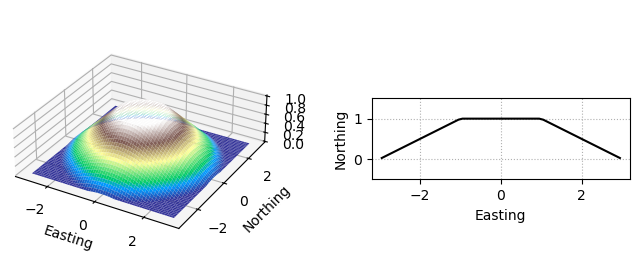

In [6]:
### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# incx, incy, incz : x, y, z方向のグリッド間隔
incx = 0.1
incy = 0.1
incz = 0.1

x = np.arange(-3.0 + 0.5*incx, 3.0, incx)
y = np.arange(-3.0 + 0.5*incy, 3.0, incy)
nx = len(x)
ny = len(y)
X, Y = np.meshgrid(x, y)

# 山型の地形
T = np.zeros(X.shape)
for iy in range(len(y)):
    for ix in range(len(x)):
        r = np.sqrt(X[iy, ix]**2 + Y[iy, ix]**2)
        if r <= 1:
            T[iy, ix] = 1.
        elif (1 <= r) and (r <= 3):
            T[iy, ix] = - 0.5*r + 1.5

### 地下グリッドの作成: xgrd, ygrd, zgrd ###
# 地下の層数 = 30  # 60×60×30
nz = 30
[yy2, zz2, xx2] = np.meshgrid(y, np.zeros(nz), x)

for k in range(nz):
    for i in range(nx):
        for j in range(ny):
            zz2[k, j, i] = T.reshape(-1)[i + nx*j] - incz / 2. - incz*k
            
xgrd = xx2.reshape(-1)
ygrd = yy2.reshape(-1)
zgrd = zz2.reshape(-1)

# 図示用
xfig, yfig, zfig = [], [], []

for i in range(len(xgrd)):
    j = i // (nx*ny)
    
    # 各グリッドの8頂点の座標を格納
    xfig.append([xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, 
                 xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx, xgrd[i] - 0.5*incx, xgrd[i] + 0.5*incx])
    yfig.append([ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy, 
                 ygrd[i] - 0.5*incy, ygrd[i] - 0.5*incy, ygrd[i] + 0.5*incy, ygrd[i] + 0.5*incy])
    zfig.append([zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, zgrd[i] - 0.5*incz, 
                 zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz, zgrd[i] + 0.5*incz])

# array化
xfig = np.array(xfig)
yfig = np.array(yfig)
zfig = np.array(zfig)

#dim: ブロックのサイズ
dim = [[incx / 2., incx / 2.], [incy / 2., incy / 2.], [incz / 2., incz / 2.]]

# 東京付近
# 偏角(度)
dec = -7.
# 伏角(度)
inc = 50.

# 図示
fig = plt.figure(figsize = (8, 4))
plt.subplots_adjust(wspace=0.4, hspace=0.)

ax = fig.add_subplot(121, projection='3d')
ax.plot_surface(X, Y, T, rstride=1, cstride=1, cmap = plt.cm.terrain)
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_box_aspect((1,1,0.3))

ax = fig.add_subplot(122)
ys = 29
ax.plot(X[ys, :], T[ys,:], color = "black")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")
ax.set_aspect("equal")
ax.set_xlim(-3.2, 3.2)
ax.set_ylim(-0.5, 1.5)
ax.grid(linestyle = "dotted")

### 空中磁気探査（南北, 100 m ASL）

CPU times: total: 22.8 s
Wall time: 55.6 s


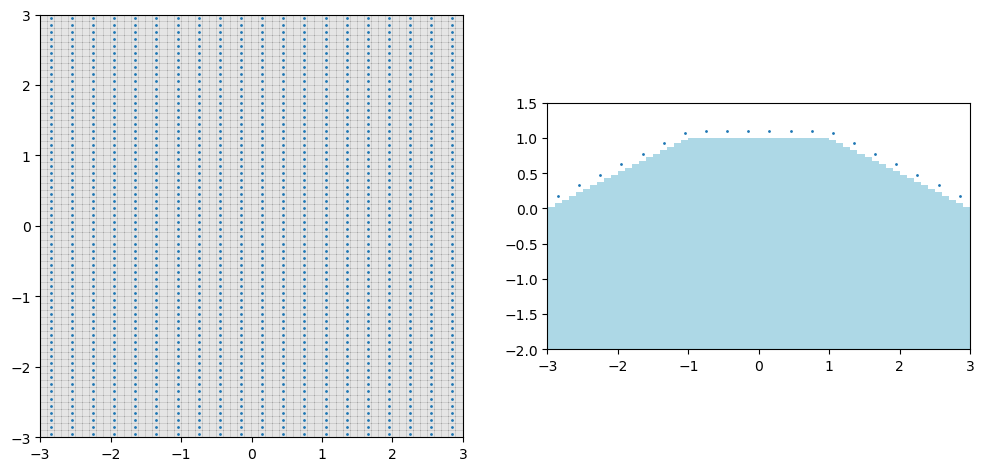

In [7]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs1, yobs1] = np.meshgrid(np.arange(-3.0 + incx + 0.5*incx, 3.0, 3*incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs1 = xobs1.reshape(-1)
yobs1 = yobs1.reshape(-1)
zobs1 = np.zeros(len(xobs1))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs1[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs1[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs1[i] = T.reshape(-1)[j] + 0.1 # 地表から100m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs1, yobs1, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs1[(0<yobs1)&(yobs1<incy)], zobs1[(0<yobs1)&(yobs1<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### 空中磁気探査（東西, 100 m ASL）

CPU times: total: 22.5 s
Wall time: 56.1 s


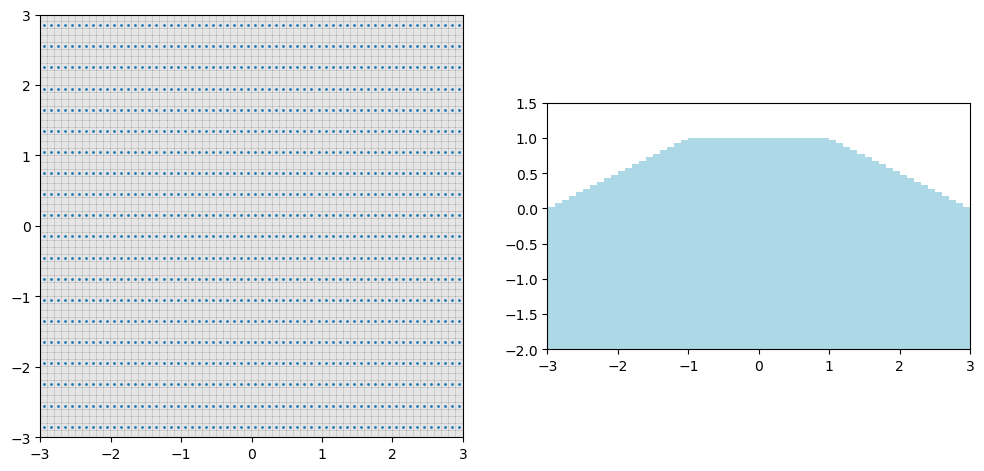

In [8]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs2, yobs2] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + incx + 0.5*incy, 3.0, 3*incy))
xobs2 = xobs2.reshape(-1)
yobs2 = yobs2.reshape(-1)
zobs2 = np.zeros(len(xobs2))

for i in range(len(xobs2)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs2[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs2[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs2[i] = T.reshape(-1)[j] + 0.1 # 地表から100m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs2, yobs2, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs2[(0<yobs2)&(yobs2<incy)], zobs2[(0<yobs2)&(yobs2<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### 空中磁気探査（南北, 60 m ASL）

CPU times: total: 25.4 s
Wall time: 14min 37s


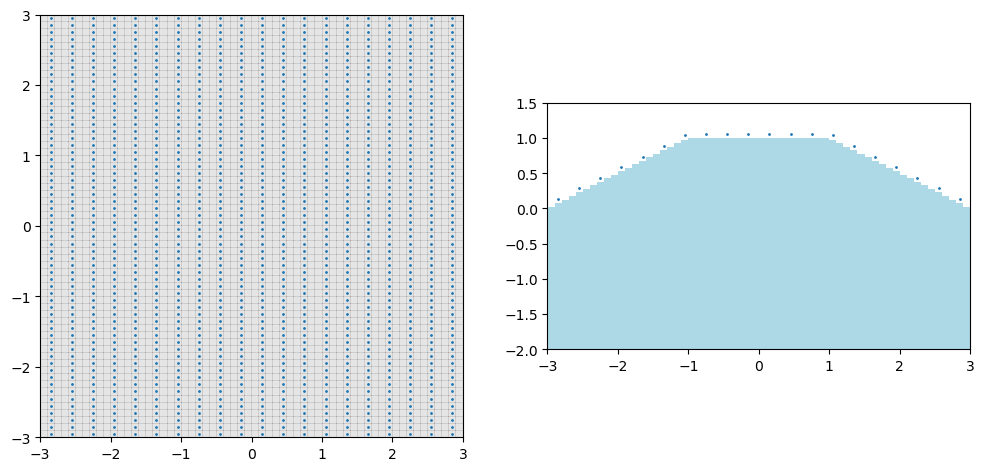

In [9]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs3, yobs3] = np.meshgrid(np.arange(-3.0 + incx + 0.5*incx, 3.0, 3*incx), np.arange(-3.0 + 0.5*incy, 3.0, incy))
xobs3 = xobs3.reshape(-1)
yobs3 = yobs3.reshape(-1)
zobs3 = np.zeros(len(xobs3))

for i in range(len(xobs1)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs3[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs3[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs3[i] = T.reshape(-1)[j] + 0.06 # 地表から60m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs3, yobs3, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs3[(0<yobs3)&(yobs3<incy)], zobs3[(0<yobs3)&(yobs3<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### 空中磁気探査（東西, 50 m ASL）

CPU times: total: 22 s
Wall time: 55.4 s


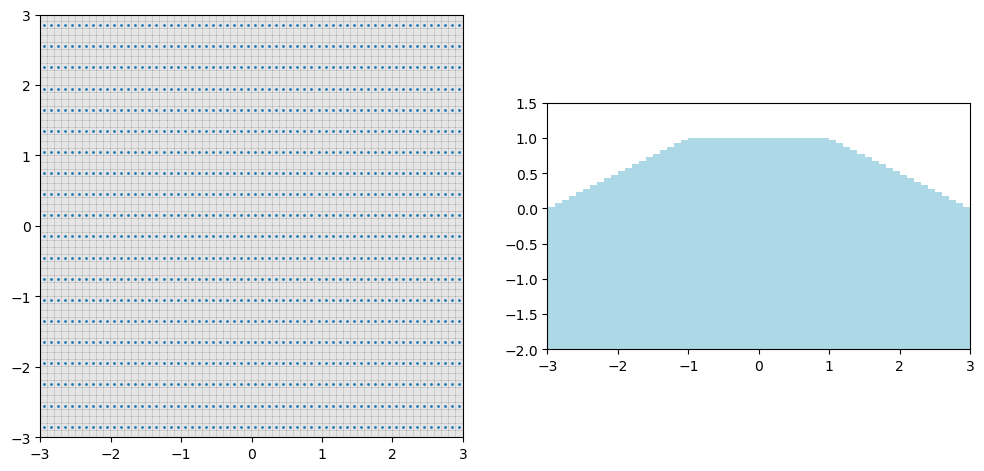

In [10]:
%%time
### 合成データの作成 ###
# 座標： x:東向きを正, y:北向きを正, z:鉛直上向きを正

### 観測点の作成: yobs, zobs ###
[xobs4, yobs4] = np.meshgrid(np.arange(-3.0 + 0.5*incx, 3.0, incx), np.arange(-3.0 + incx + 0.5*incy, 3.0, 3*incy))
xobs4 = xobs4.reshape(-1)
yobs4 = yobs4.reshape(-1)
zobs4 = np.zeros(len(xobs4))

for i in range(len(xobs4)):
    for j in range(len(X.reshape(-1))):
        if (abs(xobs4[i] - X.reshape(-1)[j]) < 1e-3) & (abs(yobs4[i] - Y.reshape(-1)[j]) < 1e-3):
            zobs4[i] = T.reshape(-1)[j] + 0.05 # 地表から50m

# 図示
from matplotlib import cm
from matplotlib.colors import Normalize
import matplotlib.colorbar as clb
from matplotlib import gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize = (12, 6))

ax = fig.add_subplot(121)
ax.pcolor(xx2[0,:,:], yy2[0,:,:], np.zeros(xx2[0,:,:].shape), cmap = "gray", alpha = 0.1)
ax.scatter(xobs4, yobs4, s = 1)
ax.set_aspect("equal")

ax = fig.add_subplot(122)

ax.scatter(xobs4[(0<yobs4)&(yobs4<incy)], zobs4[(0<yobs4)&(yobs4<incy)], s = 1)

# 断面
for i in range(len(xgrd)):
    
    # 座標
    x, y, z = xfig[i], yfig[i], zfig[i]
    x_min, x_max = min(x), max(x)
    y_min, y_max = min(y), max(y)
    z_min, z_max = min(z), max(z)
    
    # 条件
    if (y_min <= 0.5*incy) & (0.5*incy <= y_max):
        
        # 直方体の縦横
        width  = x_max - x_min
        height = z_max - z_min

        # 矩形を描画
        rect = Rectangle((x_min, z_min), width, height, facecolor="lightblue", edgecolor='white', linewidth=0.0)
        ax.add_patch(rect)

ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-2.0, 1.5)
ax.set_aspect("equal")

### 核行列

In [11]:
import pickle
with open('0403_Kernel_1_case_1_2.pickle', 'rb') as f:
    K1 = pickle.load(f)
with open('0403_Kernel_2_case_1_2.pickle', 'rb') as f:
    K2 = pickle.load(f)
with open('0403_Kernel_3_case_1_2.pickle', 'rb') as f:
    K3 = pickle.load(f)
with open('0403_Kernel_4_case_1_2.pickle', 'rb') as f:
    K4 = pickle.load(f)

In [12]:
%%time
# Depth weighting
w1 = np.linalg.norm(K1, axis=0)
X1 = K1 / w1

w2 = np.linalg.norm(K2, axis=0)
X2 = K2 / w2

w3 = np.linalg.norm(K3, axis=0)
X3 = K3 / w3

w4 = np.linalg.norm(K4, axis=0)
X4 = K4 / w4

CPU times: total: 11.4 s
Wall time: 26.6 s


### 入力モデル

Text(0.5, 1.0, 'fobs4 (nT)')

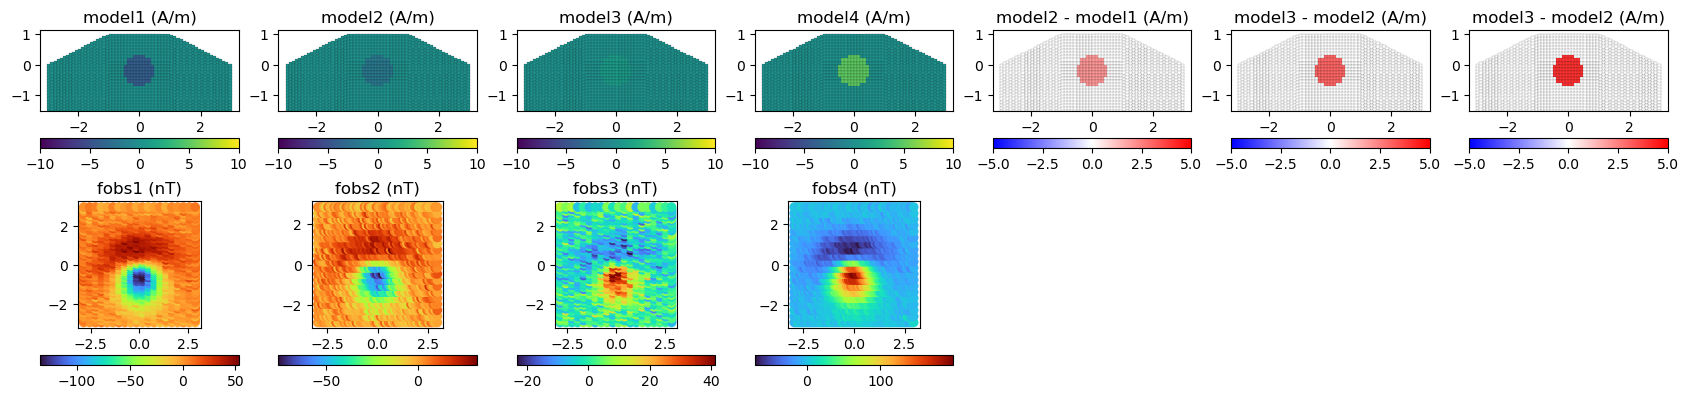

In [13]:
### 磁化構造  ###

# 回転楕円状消磁源  
zcenter = -0.2
a_rad = 0.5 # 半径
b_rad = 0.5
c_rad = 0.5

# ------------------------------------------------------------ #

# Time1
beta1 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta1[k] = -4

# Time2
beta2 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta2[k] = -2

# Time3
beta3 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta3[k] = 1

# Time4
beta4 = 0 * np.ones(len(xgrd))
for iz in range(nz):
    for iy in range(ny):
        for ix in range(nx):
            k = ix + iy*nx + iz*nx*ny
            if xgrd[k]**2 / a_rad**2 + ygrd[k]**2 / b_rad**2 + (zgrd[k] - zcenter)**2 / c_rad**2 <= 1:
                beta4[k] = 5

# ------------------------------------------------------------ #

# 磁気異常の計算
f1_row = K1.dot(beta1)
f2_row = K2.dot(beta2)
f3_row = K3.dot(beta3)
f4_row = K4.dot(beta4)

# ガウシアンノイズを加える 
np.random.seed(42)
noise1 = np.random.normal(loc=0, scale=5.0, size=len(f1_row)) # 5nT
noise2 = np.random.normal(loc=0, scale=5.0, size=len(f2_row)) # 5nT
noise3 = np.random.normal(loc=0, scale=5.0, size=len(f3_row)) # 5nT
noise4 = np.random.normal(loc=0, scale=5.0, size=len(f4_row)) # 5nT
fobs1 = f1_row + noise1
fobs2 = f2_row + noise2
fobs3 = f3_row + noise3
fobs4 = f4_row + noise4

bb1 = beta1.reshape(nz, ny, nx)
bb2 = beta2.reshape(nz, ny, nx)
bb3 = beta3.reshape(nz, ny, nx)
bb4 = beta4.reshape(nz, ny, nx)

# 図示            
fig = plt.figure(figsize = (21, 8))
ys = 29
zs = 5

ax = fig.add_subplot(371)
p = ax.scatter(xx2[:,ys,:], zz2[:,ys,:], s = 7, c = bb1[:,ys,:], marker = "s", edgecolor = "black", linewidth = 0.1)
p.set_clim(-10, 10)
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("model1 (A/m)")
#ax.grid()
#ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, )

ax = fig.add_subplot(372)
p = ax.scatter(xx2[:,ys,:], zz2[:,ys,:], s = 7, c = bb2[:,ys,:], marker = "s", edgecolor = "black", linewidth = 0.1)
p.set_clim(-10, 10)
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("model2 (A/m)")
#ax.grid()
#ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, )

ax = fig.add_subplot(373)
p = ax.scatter(xx2[:,ys,:], zz2[:,ys,:], s = 7, c = bb3[:,ys,:], marker = "s", edgecolor = "black", linewidth = 0.1)
p.set_clim(-10, 10)
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("model3 (A/m)")
#ax.grid()
#ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, )

ax = fig.add_subplot(374)
p = ax.scatter(xx2[:,ys,:], zz2[:,ys,:], s = 7, c = bb4[:,ys,:], marker = "s", edgecolor = "black", linewidth = 0.1)
p.set_clim(-10, 10)
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("model4 (A/m)")
#ax.grid()
#ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, )

ax = fig.add_subplot(375)
p = ax.scatter(xx2[:,ys,:], zz2[:,ys,:], s = 7, c = (bb2 - bb1)[:,ys,:], marker = "s", edgecolor = "black", linewidth = 0.1, cmap = "bwr")
p.set_clim(-5, 5)
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("model2 - model1 (A/m)")
#ax.grid()
#ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, )

ax = fig.add_subplot(376)
p = ax.scatter(xx2[:,ys,:], zz2[:,ys,:], s = 7, c = (bb3 - bb2)[:,ys,:], marker = "s", edgecolor = "black", linewidth = 0.1, cmap = "bwr")
p.set_clim(-5, 5)
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("model3 - model2 (A/m)")
#ax.grid()
#ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, )

ax = fig.add_subplot(377)
p = ax.scatter(xx2[:,ys,:], zz2[:,ys,:], s = 7, c = (bb4 - bb3)[:,ys,:], marker = "s", edgecolor = "black", linewidth = 0.1, cmap = "bwr")
p.set_clim(-5, 5)
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("model3 - model2 (A/m)")
#ax.grid()
#ax.set_xlim(-2, 2)
ax.set_ylim(-1.5, )

ax = fig.add_subplot(378)
p = ax.scatter(xobs1, yobs1, c = fobs1, cmap = "turbo")
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("fobs1 (nT)")

ax = fig.add_subplot(3,7,9)
p = ax.scatter(xobs2, yobs2, c = fobs2, cmap = "turbo")
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("fobs2 (nT)")

ax = fig.add_subplot(3,7,10)
p = ax.scatter(xobs3, yobs3, c = fobs3, cmap = "turbo")
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("fobs3 (nT)")

ax = fig.add_subplot(3,7,11)
p = ax.scatter(xobs4, yobs4, c = fobs4, cmap = "turbo")
plt.colorbar(p, orientation = "horizontal")
ax.set_aspect("equal")
ax.set_title("fobs4 (nT)")


(array([-3. , -1.5,  0. ,  1.5,  3. ]),
 [Text(0, -3.0, '−3.0'),
  Text(0, -1.5, '−1.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 3.0, '3.0')])

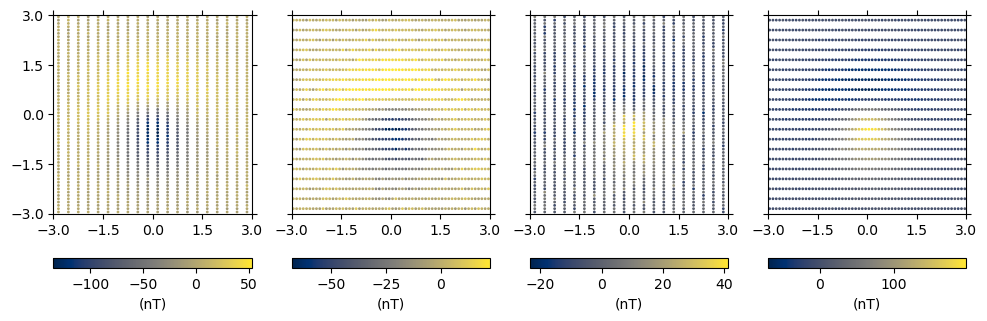

In [14]:
# 図示            
fig = plt.figure(figsize = (21, 13))

ax = fig.add_subplot(378)
p = ax.scatter(xobs1, yobs1, c = fobs1, cmap = "cividis", s = 1)
plt.colorbar(p, orientation = "horizontal", label = "(nT)")
ax.set_aspect("equal")
#ax.set_title("fobs1 (nT)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3.0, -1.5, 0.0, 1.5, 3.0])
ax.set_yticks([-3.0, -1.5, 0.0, 1.5, 3.0])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

ax = fig.add_subplot(379)
p = ax.scatter(xobs2, yobs2, c = fobs2, cmap = "cividis", s = 1)
plt.colorbar(p, orientation = "horizontal", label = "(nT)")
p.set_clim(min(K1.dot(beta2)), max(K1.dot(beta2)))
ax.set_aspect("equal")
#ax.set_title("fobs2 (nT)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3.0, -1.5, 0.0, 1.5, 3.0])
ax.set_yticks([-3.0, -1.5, 0.0, 1.5, 3.0])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.yticks(color="None")

ax = fig.add_subplot(3,7,10)
p = ax.scatter(xobs3, yobs3, c = fobs3, cmap = "cividis", s = 1)
plt.colorbar(p, orientation = "horizontal", label = "(nT)")
ax.set_aspect("equal")
#ax.set_title("fobs1 (nT)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3.0, -1.5, 0.0, 1.5, 3.0])
ax.set_yticks([-3.0, -1.5, 0.0, 1.5, 3.0])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.yticks(color="None")

ax = fig.add_subplot(3,7,11)
p = ax.scatter(xobs4, yobs4, c = fobs4, cmap = "cividis", s = 1)
plt.colorbar(p, orientation = "horizontal", label = "(nT)")
ax.set_aspect("equal")
#ax.set_title("fobs1 (nT)")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_xticks([-3.0, -1.5, 0.0, 1.5, 3.0])
ax.set_yticks([-3.0, -1.5, 0.0, 1.5, 3.0])
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.yticks(color="None")

#plt.savefig("0218_input_anomalies_T2_defict.png", dpi = 600, bbox_inches = "tight", transparent = True)

### 交点のみを抽出

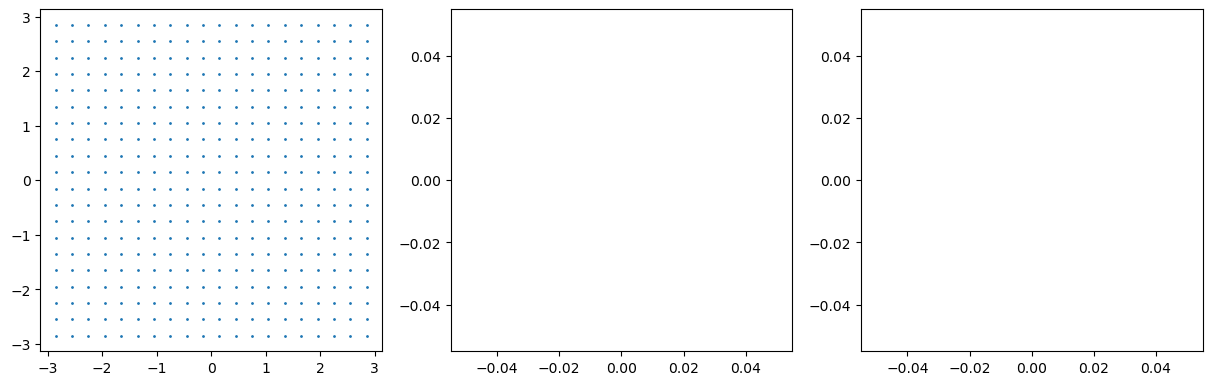

In [15]:
# diff  # T_2 - T_1
xobs_del12_all = []
yobs_del12_all = []
zobs_del12_all = []
fobs_del12_all = []

# 検索
for i in range(len(xobs1)):
    for j in range(len(xobs2)):
        
        if (np.abs(xobs1[i] - xobs2[j]) < 1e-3) & (np.abs(yobs1[i] - yobs2[j]) < 1e-3) & (np.abs(zobs1[i] - zobs2[j]) < 1e-3):

            # 座標
            xobs_del12_all.append(xobs1[i])
            yobs_del12_all.append(yobs1[i])
            zobs_del12_all.append(zobs1[i])

            # data
            fobs_del12_all.append(fobs2[j] - fobs1[i])

# diff  # T_3 - T_2
xobs_del23_all = []
yobs_del23_all = []
zobs_del23_all = []
fobs_del23_all = []

# 検索
for i in range(len(xobs2)):
    for j in range(len(xobs3)):
        
        if (np.abs(xobs2[i] - xobs3[j]) < 1e-3) & (np.abs(yobs2[i] - yobs3[j]) < 1e-3) & (np.abs(zobs2[i] - zobs3[j]) < 1e-3):

            # 座標
            xobs_del23_all.append(xobs2[i])
            yobs_del23_all.append(yobs2[i])
            zobs_del23_all.append(zobs2[i])

            # data
            fobs_del23_all.append(fobs3[j] - fobs2[i])
            
# diff  # T_4 - T_3
xobs_del34_all = []
yobs_del34_all = []
zobs_del34_all = []
fobs_del34_all = []

# 検索
for i in range(len(xobs3)):
    for j in range(len(xobs4)):
        
        if (np.abs(xobs3[i] - xobs4[j]) < 1e-3) & (np.abs(yobs3[i] - yobs4[j]) < 1e-3) & (np.abs(zobs3[i] - zobs4[j]) < 1e-3):

            # 座標
            xobs_del34_all.append(xobs3[i])
            yobs_del34_all.append(yobs3[i])
            zobs_del34_all.append(zobs3[i])

            # data
            fobs_del34_all.append(fobs4[j] - fobs3[i])

# 図示
fig = plt.figure(figsize = (15, 5))

ax1 = fig.add_subplot(131)
p = ax1.scatter(xobs_del12_all, yobs_del12_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-5, 5)
ax1.set_aspect("equal")

ax2 = fig.add_subplot(132)
p = ax2.scatter(xobs_del23_all, yobs_del23_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-15, 15)
ax2.set_aspect("equal")

ax3 = fig.add_subplot(133)
p = ax3.scatter(xobs_del34_all, yobs_del34_all, s = 1)
#plt.colorbar(p, orientation = "horizontal")
#p.set_clim(-20, 20)
ax3.set_aspect("equal")

In [16]:
len(xobs_del12_all), len(xobs_del23_all), len(xobs_del34_all), 

(400, 0, 0)

In [17]:
%%time
# threadingを用いた並列計算で核行列を求める
# 単位ベクトル作成
mgz = magcal.di2xyz(dec = dec, inc = inc)
exf = mgz.copy()

# スレッドの数（並列計算を動かす数）
n = 12

# 全グリッドに関する計算範囲 i = [0, nz] を n 個に分割
p = np.linspace(0, nz-1, n).astype(int)
p[-1] += 1
print(p)

# ThreadPool に各threadの返り値を格納させる
results = []

pool = ThreadPoolExecutor(max_workers=n-1)
for i in range(n - 1):
    p0 = p[i]
    p1 = p[i + 1]
    res = pool.submit(thread_func, p0, p1, mgz, xobs_del12_all, yobs_del12_all, zobs_del12_all, xgrd, ygrd, zgrd, dim, 1000.)
    results.append(res)

pool.shutdown()

# 計算結果を取り出し、積み上げて最終的な核行列にする
K_del12 = []
for res in results:
    Ki = res.result()
    if len(K_del12) == 0:
        K_del12 = Ki.copy()
    else:
        K_del12 = np.hstack((K_del12, Ki))

[ 0  2  5  7 10 13 15 18 21 23 26 30]
0
18000
36000
54000
65000
83000
47000
94000
76000
26000
8000
55000
37000
19000
1000
48000
66000
84000
95000
77000
27000
9000
56000
38000
49000
85000
67000
20000
2000
78000
96000
28000
57000
39000
10000
50000
68000
86000
21000
3000
79000
97000
29000
58000
40000
11000
51000
69000
87000
22000
80000
98000
4000
30000
59000
41000
52000
12000
88000
70000
81000
99000
23000
5000
31000
60000
42000
53000
89000
71000
13000
82000
100000
24000
6000
32000
61000
43000
90000
72000
14000
101000
25000
7000
33000
62000
44000
73000
91000
15000
102000
34000
63000
45000
92000
74000
16000
103000
35000
64000
46000
75000
93000
17000
104000
105000
106000
107000
CPU times: total: 1h 1min 31s
Wall time: 56min 43s


In [18]:
# Depth weighting
w_del12 = np.linalg.norm(K_del12, axis=0)
X_del12 = K_del12 / w_del12
XXT_del12 = X_del12.dot(X_del12.T)

X_del12.shape, 

((400, 108000),)

### Differential Inversion

In [19]:
# hyper-parameters
lams = np.power(10., np.arange(0.0, 2.6, 0.25))
print("lams = {}".format(lams))

# ratio of L1 norm and L2 norm
alpha_ = 0.9

lams = [  1.           1.77827941   3.16227766   5.62341325  10.
  17.7827941   31.6227766   56.23413252 100.         177.827941
 316.22776602]


In [20]:
%%time
params_all = []
betas_del12_all = []

for li in range(len(lams)):

    params_all.append(lams[li])
    
    l_1 = lams[li] * alpha_
    l_2 = lams[li] * (1. - alpha_)
    print("λ1 = {}, λ2 = {}".format(l_1, l_2))
    
    # インバージョン解析を実行
    model1 = L1L2(l_1, l_2, rho_=1.0, eta_=0.0, fit_intercept = False, eps_ADMM = 1.e-3)
    model1.algorithm(X_del12, fobs_del12_all, w_del12)
    beta_sim_del12 = model1.beta_ / w_del12

    betas_del12_all.append(beta_sim_del12)

# ndarry
params_all = np.array(params_all)
betas_del12_all = np.array(betas_del12_all)

λ1 = 0.9, λ2 = 0.09999999999999998
intercept = False
no-constrained
iter = 0, delta = 0.08646416027922767
113
λ1 = 1.6004514690350304, λ2 = 0.17782794100389224
intercept = False
no-constrained
iter = 0, delta = 0.0876570956694019
197
λ1 = 2.8460498941515415, λ2 = 0.3162277660168379
intercept = False
no-constrained
iter = 0, delta = 0.0876570956694019
353
λ1 = 5.061071926713142, λ2 = 0.562341325190349
intercept = False
no-constrained
iter = 0, delta = 0.0876570956694019
610
λ1 = 9.0, λ2 = 0.9999999999999998
intercept = False
no-constrained
iter = 0, delta = 0.0876570956694019
989
λ1 = 16.004514690350305, λ2 = 1.7782794100389225
intercept = False
no-constrained
iter = 0, delta = 0.0876570956694019
iter = 1000, delta = 0.001287678553505559
1434
λ1 = 28.460498941515414, λ2 = 3.1622776601683786
intercept = False
no-constrained
iter = 0, delta = 0.0876570956694019
iter = 1000, delta = 0.0018752815580394316
iter = 2000, delta = 0.0010443856363876838
2116
λ1 = 50.610719267131415, λ2 = 5.623413

In [21]:
import pickle
with open('0403_params_differential_case_1_2.pickle', 'wb') as f:
    pickle.dump(params_all, f)
with open('0403_betas_del12_differential_case_1_2.pickle', 'wb') as f:
    pickle.dump(betas_del12_all, f)

In [22]:
# calc rss, pen
# T2 - T1
rss_temp_del12 = []
pen_temp_del12 = []
for i in range(len(lams)):
    rss_temp_del12.append(misfit(fobs_del12_all, K_del12, betas_del12_all[i]))
    pen_temp_del12.append(pen(betas_del12_all[i]*w_del12, alpha=0.9))

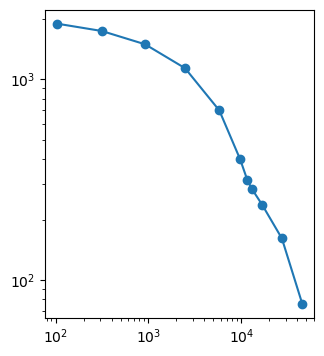

In [23]:
# L-curve
fig = plt.figure(figsize = (16, 4))

ax = fig.add_subplot(141)
ax.loglog(rss_temp_del12, pen_temp_del12, "o-")
#ax.plot(rss_temp_del12, pen_temp_del12, "o-")


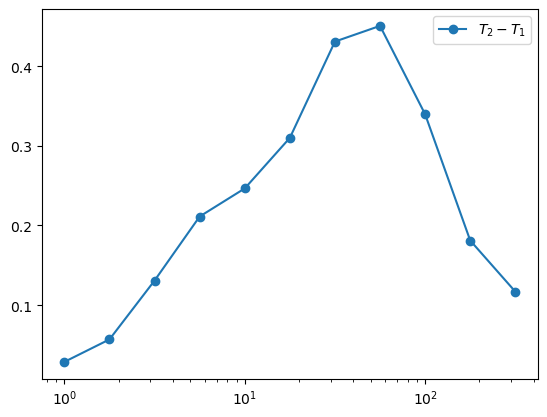

In [24]:
plt.semilogx(lams, calcCurvature2(np.log(rss_temp_del12), np.log(pen_temp_del12)), "o-", label = "$T_2 - T_1$")
plt.legend()